<a href="https://colab.research.google.com/github/tonywahome/linear_regression_model/blob/main/Anxiety_Predicting_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Required Libraries

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



## Load Datasets

In [16]:
suicide_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\summative\linear_regression\mental_health_data\suicide_rates_2019.csv')
mental_health_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\summative\linear_regression\mental_health_data\Mental health Depression disorder Data.csv')
anxiety_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\summative\linear_regression\mental_health_data\prevalence-of-anxiety-disorders-males-vs-females.csv')
bipolar_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\summative\linear_regression\mental_health_data\prevalence-of-bipolar-disorder-in-males-vs-females.csv')
eating_disorder_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\summative\linear_regression\mental_health_data\prevalence-of-eating-disorders-in-males-vs-females.csv')
schizophrenia_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\summative\linear_regression\mental_health_data\prevalence-of-schizophrenia-in-males-vs-females.csv')
road_deaths_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\summative\linear_regression\mental_health_data\road_death_2019.csv')
suicide_rate_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\summative\linear_regression\mental_health_data\suicide-rate-by-country-2023.csv')
worldHappiness_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\summative\linear_regression\mental_health_data\World Happiness Report 2005-2021.csv')
depression_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\summative\linear_regression\mental_health_data\prevalence-of-depression-males-vs-females.csv')



display(mental_health_df)
display(anxiety_df)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8936\3673641687.py:2: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  mental_health_df = pd.read_csv(r'C:\Users\LENOVO\Cloned repos\lrm_summative\linear_regression_model\summative\linear_regression\mental_health_data\Mental health Depression disorder Data.csv')


,index,Entity,Code,Year,Schizophrenia (%),Bipolar disorder (%),Eating disorders (%),Anxiety disorders (%),Drug use disorders (%),Depression (%),Alcohol use disorders (%)
0,0,Afghanistan,AFG,1990,0.16056,0.697779,0.101855,4.828830,1.677082,4.071831,0.672404
1,1,Afghanistan,AFG,1991,0.160312,0.697961,0.099313,4.829740,1.684746,4.079531,0.671768
2,2,Afghanistan,AFG,1992,0.160135,0.698107,0.096692,4.831108,1.694334,4.088358,0.670644
3,3,Afghanistan,AFG,1993,0.160037,0.698257,0.094336,4.830864,1.705320,4.096190,0.669738
4,4,Afghanistan,AFG,1994,0.160022,0.698469,0.092439,4.829423,1.716069,4.099582,0.669260
...,...,...,...,...,...,...,...,...,...,...,...
108548,108548,Zimbabwe,ZWE,2013,303564.60359,NaN,NaN,NaN,NaN,NaN,NaN
108549,108549,Zimbabwe,ZWE,2014,311665.769283,NaN,NaN,NaN,NaN,NaN,NaN
108550,108550,Zimbabwe,ZWE,2015,320638.507158,NaN,NaN,NaN,NaN,NaN,NaN
108551,108551,Zimbabwe,ZWE,2016,330437.353798,NaN,NaN,NaN,NaN,NaN,NaN


,index,Entity,Code,Year,Prevalence - Anxiety disorders - Sex: Male - Age: Age-standardized (Percent),Prevalence - Anxiety disorders - Sex: Female - Age: Age-standardized (Percent),Population (historical estimates),Continent
0,0,Abkhazia,OWID_ABK,2015,NaN,NaN,NaN,Asia
1,1,Afghanistan,AFG,1990,3.556843,5.971172,12412311.0,NaN
2,2,Afghanistan,AFG,1991,3.548885,5.980482,13299016.0,NaN
3,3,Afghanistan,AFG,1992,3.542779,5.988175,14485543.0,NaN
4,4,Afghanistan,AFG,1993,3.538304,5.993858,15816601.0,NaN
...,...,...,...,...,...,...,...,...
56390,56390,Zimbabwe,ZWE,1988,NaN,NaN,9849129.0,NaN
56391,56391,Zimbabwe,ZWE,1989,NaN,NaN,10153852.0,NaN
56392,56392,Zimbabwe,ZWE,2020,NaN,NaN,14862927.0,NaN
56393,56393,Zimbabwe,ZWE,2021,NaN,NaN,15092171.0,NaN


In [17]:
# Ensure 'Year' columns are of the same type before merging
mental_health_df['Year'] = pd.to_numeric(mental_health_df['Year'], errors='coerce')
anxiety_df['Year'] = pd.to_numeric(anxiety_df['Year'], errors='coerce')

# Drop rows with NaN in 'Year' after conversion
mental_health_df = mental_health_df.dropna(subset=['Year'])
anxiety_df = anxiety_df.dropna(subset=['Year'])

# Convert 'Year' to int after dropping NaNs
mental_health_df['Year'] = mental_health_df['Year'].astype(int)
anxiety_df['Year'] = anxiety_df['Year'].astype(int)

# initialize master_df with mental_health_df and merge with anxiety_df
master_df = pd.merge(
	mental_health_df,
	anxiety_df,
	how='inner',
	left_on=['Entity', 'Year'],
	right_on=['Entity', 'Year']
)

# Display the merged DataFrame
display(master_df)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_8936\2045933921.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mental_health_df['Year'] = mental_health_df['Year'].astype(int)


,index_x,Entity,Code_x,Year,Schizophrenia (%),Bipolar disorder (%),Eating disorders (%),Anxiety disorders (%),Drug use disorders (%),Depression (%),Alcohol use disorders (%),index_y,Code_y,Prevalence - Anxiety disorders - Sex: Male - Age: Age-standardized (Percent),Prevalence - Anxiety disorders - Sex: Female - Age: Age-standardized (Percent),Population (historical estimates),Continent
0,0,Afghanistan,AFG,1990,0.16056,0.697779,0.101855,4.828830,1.677082,4.071831,0.672404,1,AFG,3.556843,5.971172,12412311.0,NaN
1,1,Afghanistan,AFG,1991,0.160312,0.697961,0.099313,4.829740,1.684746,4.079531,0.671768,2,AFG,3.548885,5.980482,13299016.0,NaN
2,2,Afghanistan,AFG,1992,0.160135,0.698107,0.096692,4.831108,1.694334,4.088358,0.670644,3,AFG,3.542779,5.988175,14485543.0,NaN
3,3,Afghanistan,AFG,1993,0.160037,0.698257,0.094336,4.830864,1.705320,4.096190,0.669738,4,AFG,3.538304,5.993858,15816601.0,NaN
4,4,Afghanistan,AFG,1994,0.160022,0.698469,0.092439,4.829423,1.716069,4.099582,0.669260,5,AFG,3.535309,5.997363,17075728.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103443,108548,Zimbabwe,ZWE,2013,303564.60359,NaN,NaN,NaN,NaN,NaN,NaN,56158,ZWE,3.044492,3.512828,13350378.0,NaN
103444,108549,Zimbabwe,ZWE,2014,311665.769283,NaN,NaN,NaN,NaN,NaN,NaN,56159,ZWE,3.045145,3.523853,13586710.0,NaN
103445,108550,Zimbabwe,ZWE,2015,320638.507158,NaN,NaN,NaN,NaN,NaN,NaN,56160,ZWE,3.047380,3.533207,13814642.0,Africa
103446,108551,Zimbabwe,ZWE,2016,330437.353798,NaN,NaN,NaN,NaN,NaN,NaN,56161,ZWE,3.045751,3.549726,14030338.0,NaN


## Clean mental health DataFrame

Filter nulls



In [18]:
mental_health_df = mental_health_df.dropna()
display(mental_health_df)


print(mental_health_df.info())

,index,Entity,Code,Year,Schizophrenia (%),Bipolar disorder (%),Eating disorders (%),Anxiety disorders (%),Drug use disorders (%),Depression (%),Alcohol use disorders (%)
0,0,Afghanistan,AFG,1990,0.16056,0.697779,0.101855,4.828830,1.677082,4.071831,0.672404
1,1,Afghanistan,AFG,1991,0.160312,0.697961,0.099313,4.829740,1.684746,4.079531,0.671768
2,2,Afghanistan,AFG,1992,0.160135,0.698107,0.096692,4.831108,1.694334,4.088358,0.670644
3,3,Afghanistan,AFG,1993,0.160037,0.698257,0.094336,4.830864,1.705320,4.096190,0.669738
4,4,Afghanistan,AFG,1994,0.160022,0.698469,0.092439,4.829423,1.716069,4.099582,0.669260
...,...,...,...,...,...,...,...,...,...,...,...
6463,6463,Zimbabwe,ZWE,2013,0.15567,0.607993,0.117248,3.090168,0.766280,3.128192,1.515641
6464,6464,Zimbabwe,ZWE,2014,0.155993,0.60861,0.118073,3.093964,0.768914,3.140290,1.515470
6465,6465,Zimbabwe,ZWE,2015,0.156465,0.609363,0.11947,3.098687,0.771802,3.155710,1.514751
6466,6466,Zimbabwe,ZWE,2016,0.157111,0.610234,0.121456,3.104294,0.772275,3.174134,1.513269


<class 'pandas.core.frame.DataFrame'>
Index: 5488 entries, 0 to 6467
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   index                      5488 non-null   int64  
 1   Entity                     5488 non-null   object 
 2   Code                       5488 non-null   object 
 3   Year                       5488 non-null   int64  
 4   Schizophrenia (%)          5488 non-null   object 
 5   Bipolar disorder (%)       5488 non-null   object 
 6   Eating disorders (%)       5488 non-null   object 
 7   Anxiety disorders (%)      5488 non-null   float64
 8   Drug use disorders (%)     5488 non-null   float64
 9   Depression (%)             5488 non-null   float64
 10  Alcohol use disorders (%)  5488 non-null   float64
dtypes: float64(4), int64(2), object(5)
memory usage: 514.5+ KB
None


In [19]:
# change schizophrenia(%), bipolar(%), Eating disorders (%) to float
mental_health_df['Schizophrenia (%)'] = mental_health_df['Schizophrenia (%)'].astype(float)
mental_health_df['Bipolar disorder (%)'] = mental_health_df['Bipolar disorder (%)'].astype(float)
mental_health_df['Eating disorders (%)'] = mental_health_df['Eating disorders (%)'].astype(float)

#convert year to int
mental_health_df['Year'] = mental_health_df['Year'].astype(int)
print(mental_health_df.info())
                                                

<class 'pandas.core.frame.DataFrame'>
Index: 5488 entries, 0 to 6467
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   index                      5488 non-null   int64  
 1   Entity                     5488 non-null   object 
 2   Code                       5488 non-null   object 
 3   Year                       5488 non-null   int64  
 4   Schizophrenia (%)          5488 non-null   float64
 5   Bipolar disorder (%)       5488 non-null   float64
 6   Eating disorders (%)       5488 non-null   float64
 7   Anxiety disorders (%)      5488 non-null   float64
 8   Drug use disorders (%)     5488 non-null   float64
 9   Depression (%)             5488 non-null   float64
 10  Alcohol use disorders (%)  5488 non-null   float64
dtypes: float64(7), int64(2), object(2)
memory usage: 514.5+ KB
None


In [20]:
display(mental_health_df)

,index,Entity,Code,Year,Schizophrenia (%),Bipolar disorder (%),Eating disorders (%),Anxiety disorders (%),Drug use disorders (%),Depression (%),Alcohol use disorders (%)
0,0,Afghanistan,AFG,1990,0.160560,0.697779,0.101855,4.828830,1.677082,4.071831,0.672404
1,1,Afghanistan,AFG,1991,0.160312,0.697961,0.099313,4.829740,1.684746,4.079531,0.671768
2,2,Afghanistan,AFG,1992,0.160135,0.698107,0.096692,4.831108,1.694334,4.088358,0.670644
3,3,Afghanistan,AFG,1993,0.160037,0.698257,0.094336,4.830864,1.705320,4.096190,0.669738
4,4,Afghanistan,AFG,1994,0.160022,0.698469,0.092439,4.829423,1.716069,4.099582,0.669260
...,...,...,...,...,...,...,...,...,...,...,...
6463,6463,Zimbabwe,ZWE,2013,0.155670,0.607993,0.117248,3.090168,0.766280,3.128192,1.515641
6464,6464,Zimbabwe,ZWE,2014,0.155993,0.608610,0.118073,3.093964,0.768914,3.140290,1.515470
6465,6465,Zimbabwe,ZWE,2015,0.156465,0.609363,0.119470,3.098687,0.771802,3.155710,1.514751
6466,6466,Zimbabwe,ZWE,2016,0.157111,0.610234,0.121456,3.104294,0.772275,3.174134,1.513269


## Explolatory Data Analysis

Data Visualizations to investigate relationships

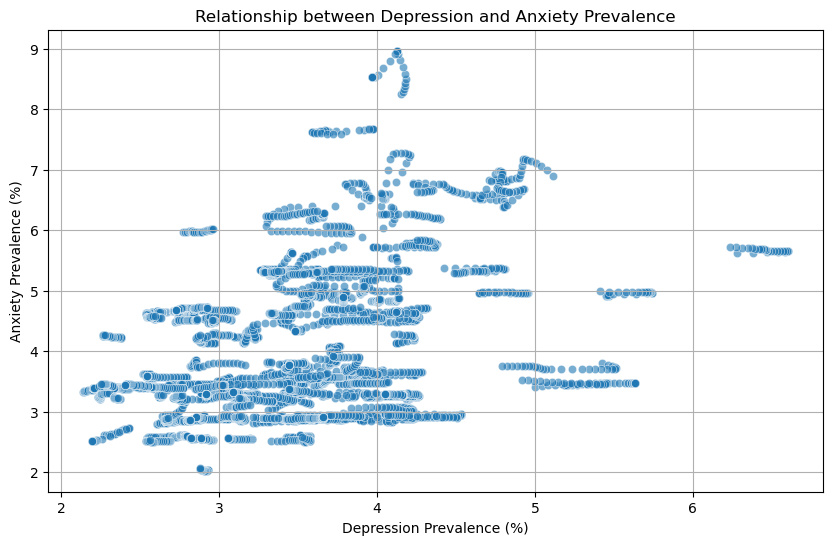

In [21]:
# scatter plot showing the relationship between depression and anxiety
plt.figure(figsize=(10, 6))
sns.scatterplot(data=mental_health_df, x='Depression (%)', y='Anxiety disorders (%)', alpha=0.6)
plt.title('Relationship between Depression and Anxiety Prevalence')
plt.xlabel('Depression Prevalence (%)')
plt.ylabel('Anxiety Prevalence (%)')
plt.grid(True)
plt.show()

# moderate positive correlation between the two variables. 
# This means that as the prevalence of depression (%) increases,
# the prevalence of anxiety (%) also tends to increase.
# clustering of data points, indicating that there are groups of countries with similar levels of depression and anxiety prevalence.
# comorbidity btn depression and anxiety

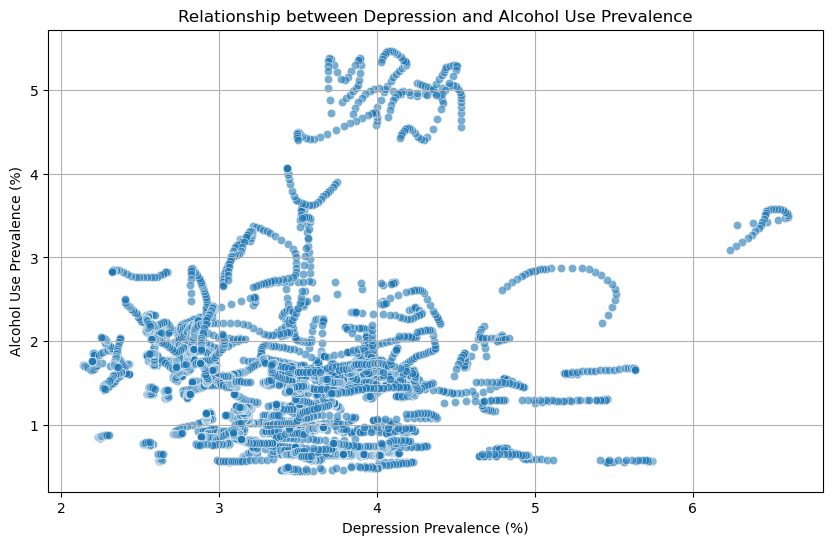

In [22]:
# scatter plot showing the relationship between depression and alcohol use

plt.figure(figsize=(10, 6))
sns.scatterplot(data=mental_health_df, x='Depression (%)', y='Alcohol use disorders (%)', alpha=0.6)
plt.title('Relationship between Depression and Alcohol Use Prevalence')
plt.xlabel('Depression Prevalence (%)')
plt.ylabel('Alcohol Use Prevalence (%)')   
plt.grid(True)
plt.show()

# no clear correlation between the two variables.

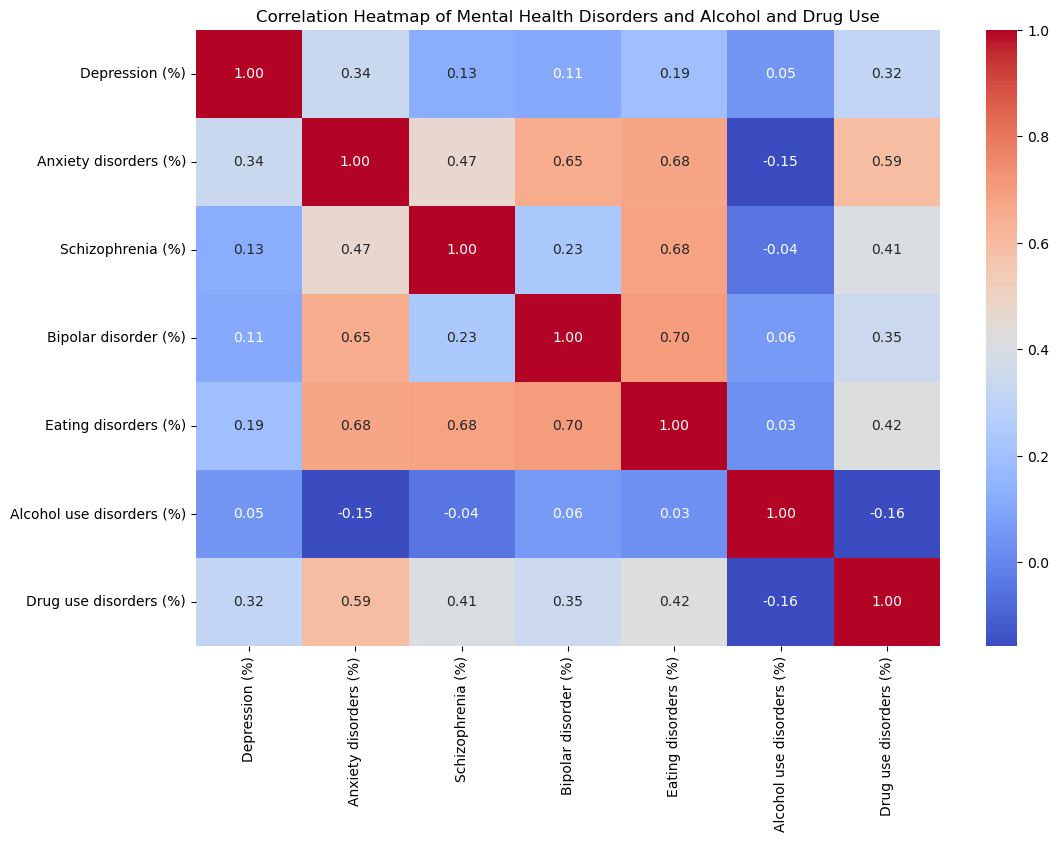

In [23]:
# heatmap showing the correlation between depression, anxiety, schizophrenia, bipolar, eating disorder and alcohol use and drug use disorders
plt.figure(figsize=(12, 8))
correlation_matrix = mental_health_df[['Depression (%)', 'Anxiety disorders (%)', 'Schizophrenia (%)', 'Bipolar disorder (%)', 'Eating disorders (%)', 'Alcohol use disorders (%)', 'Drug use disorders (%)']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Mental Health Disorders and Alcohol and Drug Use')
plt.show() 

There are strong positive correlations among several mental health disorders, suggesting they often occur together. The strongest pairs are:

- Bipolar disorder and Eating disorders (r=0.70)

- Anxiety and Eating disorders (r=0.68)

- Schizophrenia and Eating disorders (r=0.68)

- Anxiety and Bipolar disorder (r=0.65)

To investigate further it is rational to create interaction terms to visualize much more complex relationships


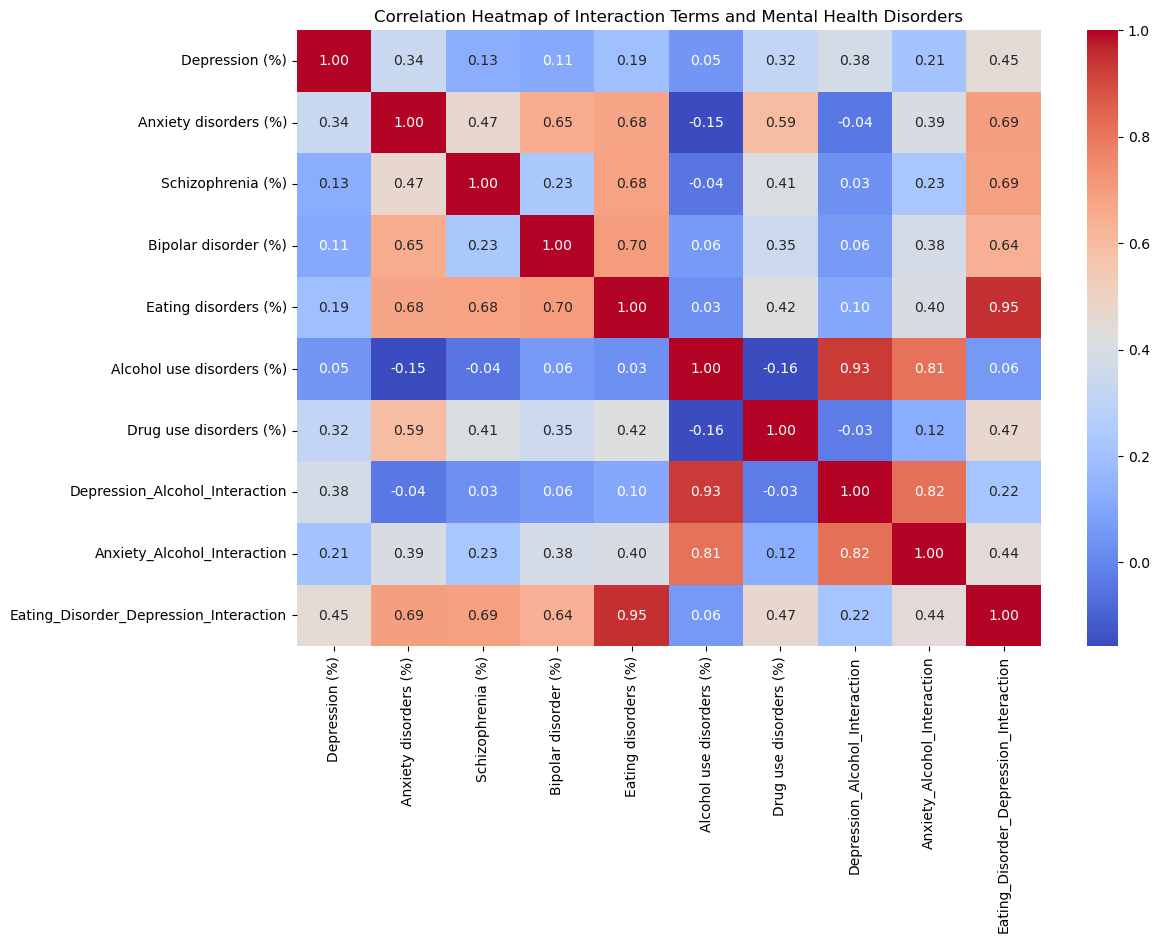

In [24]:
# create interaction terms to visualize much more complex relationships
mental_health_df['Depression_Alcohol_Interaction'] = mental_health_df['Depression (%)'] * mental_health_df['Alcohol use disorders (%)']
mental_health_df['Anxiety_Alcohol_Interaction'] = mental_health_df['Anxiety disorders (%)'] * mental_health_df['Alcohol use disorders (%)']
mental_health_df['Eating_Disorder_Depression_Interaction'] = mental_health_df['Eating disorders (%)'] * mental_health_df['Depression (%)']


# Select all columns for correlation calculation, including the new interaction terms
interaction_correlation_matrix = mental_health_df[['Depression (%)', 'Anxiety disorders (%)', 'Schizophrenia (%)', 'Bipolar disorder (%)', 'Eating disorders (%)', 'Alcohol use disorders (%)', 'Drug use disorders (%)',
                                                   'Depression_Alcohol_Interaction', 'Anxiety_Alcohol_Interaction', 'Eating_Disorder_Depression_Interaction']].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(interaction_correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Interaction Terms and Mental Health Disorders')
plt.show()


**MODEL TRAINING**

80/20 Train/Test split

In [25]:
# Define features (X) and target (y)
# Drop non-numeric and target columns
X = mental_health_df.drop(columns=['Entity', 'Year', 'Depression (%)', 'Anxiety disorders (%)'])
y = mental_health_df['Anxiety disorders (%)']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Training set shape: (4390, 10) (4390,)
Testing set shape: (1098, 10) (1098,)


## Model Evaluation

Label encoder

Initiate Linear Regression Func

In [29]:
# Encode only the 'Code' column using LabelEncoder
le = LabelEncoder()
X_train = X_train.copy()
X_test = X_test.copy()
X_train['Code'] = le.fit_transform(X_train['Code'])
X_test['Code'] = le.transform(X_test['Code'])

model = LinearRegression()
model.fit(X_train, y_train)

print("Model coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Model coefficients: [-4.23520765e-05  2.03960274e-03  1.08410950e+00  1.54598021e+00
  9.62028070e-01  5.24775138e-01 -1.59385772e+00  4.96067378e-02
  3.90643688e-01 -2.80353350e-01]
Intercept: 1.9929341416637114


In [30]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)



Mean Squared Error: 0.1272374681064773
R-squared: 0.8995523838126391


In [ ]:
#check coefficients
print("n\Feature Impact on Anxiety")
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)
print(coefficients)

n\Feature Impact on Anxiety
                                  Feature  Coefficient
1                                    Code     0.002110
8             Anxiety_Alcohol_Interaction     0.001306
4                    Eating disorders (%)     0.000214
7          Depression_Alcohol_Interaction     0.000176
3                    Bipolar disorder (%)     0.000121
5                  Drug use disorders (%)     0.000099
2                       Schizophrenia (%)    -0.000011
0                                   index    -0.000082
9  Eating_Disorder_Depression_Interaction    -0.000205
6               Alcohol use disorders (%)    -0.001380


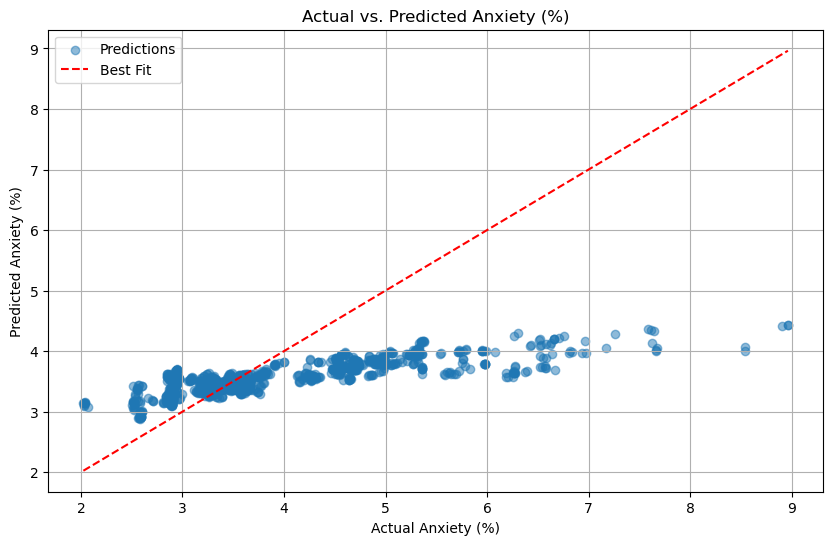

In [ ]:
#plot linear regression line of actual anxiety vs predicted anxiety
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, label='Predictions')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label = "Best Fit")
plt.xlabel('Actual Anxiety (%)')
plt.ylabel('Predicted Anxiety (%)')
plt.title('Actual vs. Predicted Anxiety (%)')
plt.grid(True)
plt.legend()
plt.show()

# Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestRegressor


In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

Predictions

In [ ]:
y_pred_rf = rf_model.predict(X_test)

In [ ]:
#evaluate
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

In [ ]:
print("Random Forest - Mean Squared Error:", mse_rf)
print("Random Forest - R-squared:", r2_rf)

Random Forest - Mean Squared Error: 1.561332261974687
Random Forest - R-squared: -0.23259371728879508


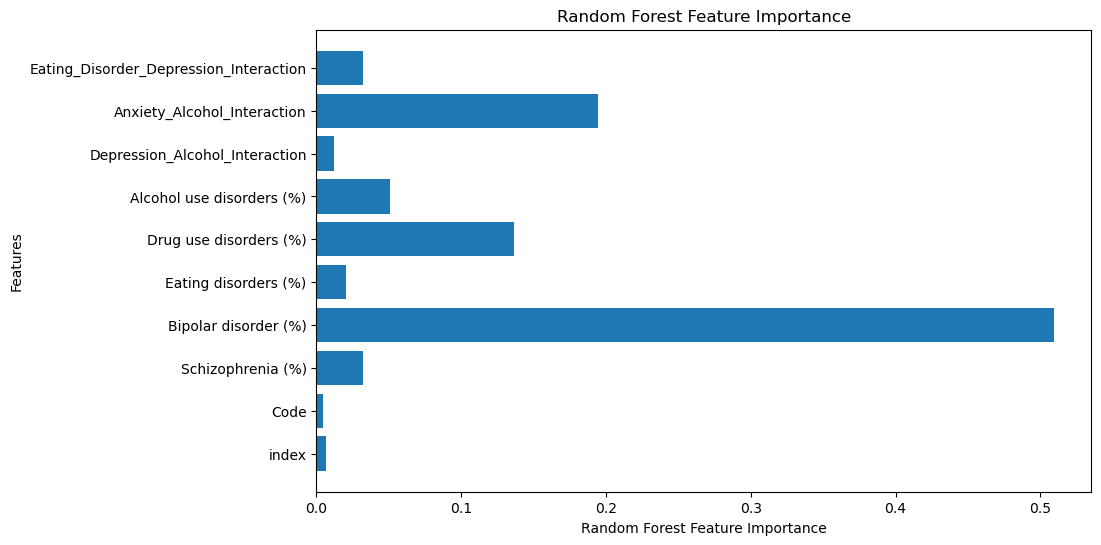

In [ ]:
# get feature importances
importances = rf_model.feature_importances_
features = X.columns

plt.figure(figsize=(10, 6))
plt.barh(features, importances)
plt.xlabel('Random Forest Feature Importance')
plt.ylabel('Features')
plt.title('Random Forest Feature Importance')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42),
                           param_grid, cv=5, scoring='r2'
                        )

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Best Parameters:", best_params)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


## Decision Tree Model

In [ ]:
from sklearn.tree import DecisionTreeRegressor


In [ ]:
dt_model = DecisionTreeRegressor(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=5, random_state=42)

In [ ]:
y_pred_dt = dt_model.predict(X_test)

In [ ]:
#evaluate
mse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree - Mean Squared Error:", mse_dt)
print("Decision Tree - R-squared:", r2_dt)

Decision Tree - Mean Squared Error: 0.3359693335839866
Decision Tree - R-squared: 0.9298259323266846


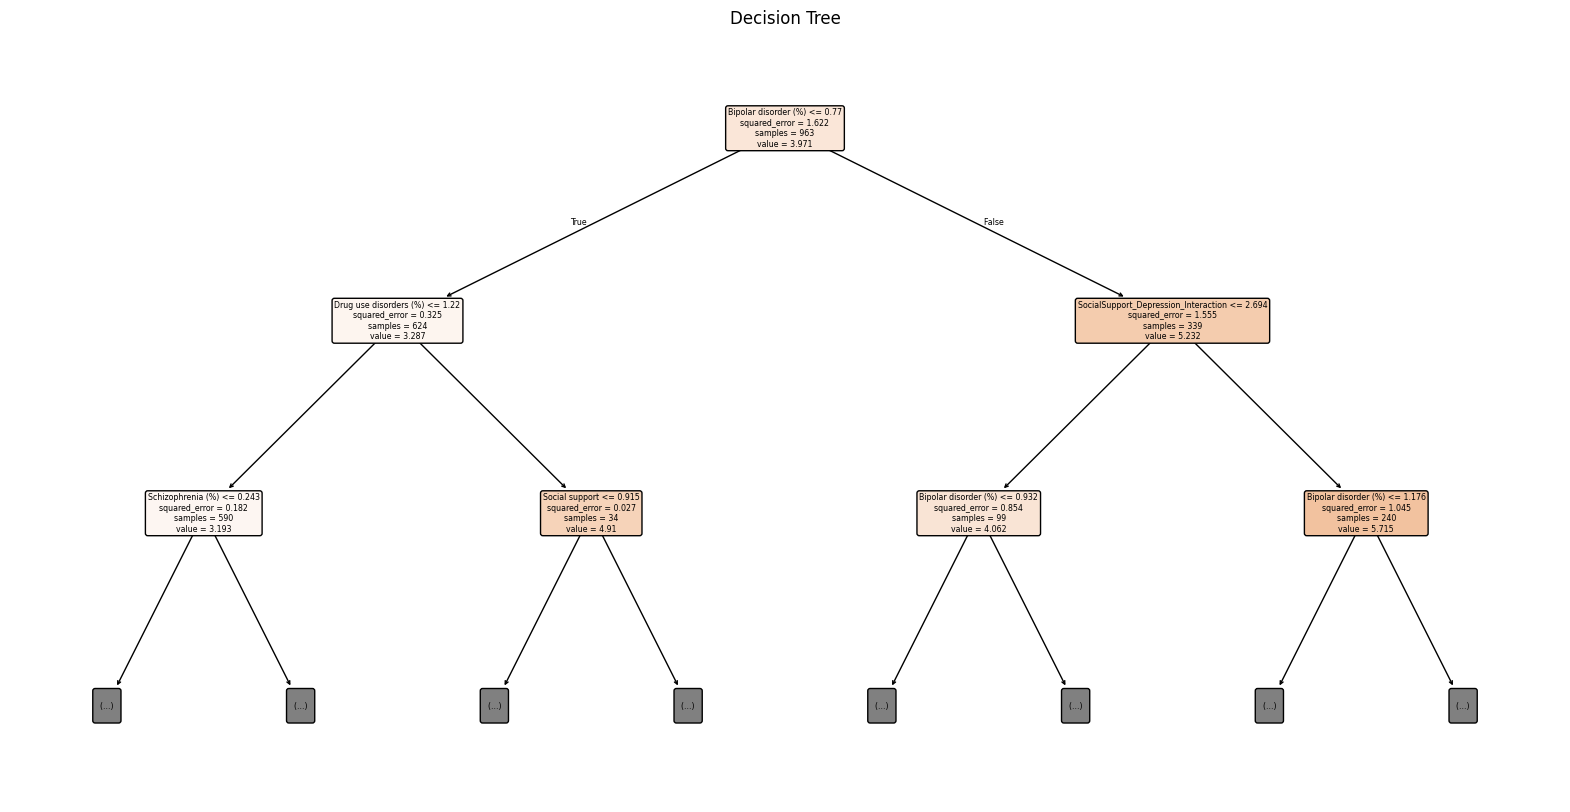

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt_model, filled=True, feature_names=X.columns, rounded=True, max_depth=2)
plt.title('Decision Tree')
plt.show()

## Model Comparison


In [ ]:
#compare models
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Decision Tree'],
    'Mean Squared Error': [mse, mse_rf, mse_dt],
    'R-squared': [r2, r2_rf, r2_dt]
}).sort_values(by='R-squared', ascending=False)

print(results)

               Model  Mean Squared Error  R-squared
1      Random Forest            0.012570   0.992185
2      Decision Tree            0.335969   0.929826
0  Linear Regression            0.538555   0.665183


Since the Random Forest Model has the lowest Mean Squared Error and the Highest R Squared Value, it is the most appropriate model

In [ ]:
import joblib

In [ ]:
joblib.dump(rf_model, 'anxiety_model.pkl')

['anxiety_model.pkl']

In [ ]:
import joblib

# Load the saved model
loaded_model = joblib.load('/content/anxiety_model.pkl')

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
display(master_df)
master_df.info()

,Country,year,Suicide Rate,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Negative affect,...,Population (historical estimates)_x,Continent_x,index_y,Entity_y,Code_y,Year_y,Prevalence - Anxiety disorders - Sex: Male - Age: Age-standardized (Percent)_y,Prevalence - Anxiety disorders - Sex: Female - Age: Age-standardized (Percent)_y,Population (historical estimates)_y,Continent_y
0,Serbia,2017,0.33,9.717821,0.883770,66.650002,0.684846,-0.079366,0.851458,0.326407,...,8829623.0,NaN,43827,Serbia,SRB,2017,2.624738,4.500026,8829623.0,NaN
1,Niger,2017,10.15,7.058953,0.582110,54.799999,0.683558,-0.029409,0.777660,0.426522,...,21602388.0,NaN,35367,Niger,NER,2017,2.622831,3.409168,21602388.0,NaN
2,Uganda,2017,10.34,7.637549,0.739956,57.250000,0.772344,0.060091,0.815770,0.400026,...,41166588.0,NaN,52101,Uganda,UGA,2017,3.611020,4.680541,41166588.0,NaN
3,Switzerland,2017,10.37,11.143362,0.949661,72.099998,0.924997,0.174821,0.316183,0.195871,...,8455797.0,NaN,48361,Switzerland,CHE,2017,5.601684,9.379139,8455797.0,NaN
4,Norway,2017,10.38,11.067431,0.950128,71.300003,0.953017,0.232320,0.249711,0.202914,...,5296324.0,NaN,36868,Norway,NOR,2017,5.714760,8.851221,5296324.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199,Mali,2006,8.65,7.592722,0.761116,49.939999,0.555076,-0.071363,0.761046,0.208563,...,13203378.0,NaN,29875,Mali,MLI,2006,2.311528,3.011982,13203378.0,NaN
1200,Nigeria,2006,9.16,8.326130,0.735179,50.220001,0.649140,0.084604,0.870749,0.178237,...,142538305.0,NaN,35615,Nigeria,NGA,2006,2.473781,3.312679,142538305.0,NaN
1201,Uzbekistan,2006,9.59,8.255723,0.903067,61.340000,0.784301,-0.120173,0.608808,0.195058,...,26804067.0,NaN,53755,Uzbekistan,UZB,2006,1.627055,2.568980,26804067.0,NaN
1202,Chile,2006,9.72,9.883473,0.835544,67.779999,0.744292,0.164268,0.633630,0.347657,...,16354507.0,NaN,10044,Chile,CHL,2006,3.257836,8.617663,16354507.0,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1204 entries, 0 to 1203
Data columns (total 33 columns):
 #   Column                                                                            Non-Null Count  Dtype  
---  ------                                                                            --------------  -----  
 0   Country                                                                           1204 non-null   object 
 1   year                                                                              1204 non-null   int64  
 2   Suicide Rate                                                                      1204 non-null   float64
 3   Log GDP per capita                                                                1204 non-null   float64
 4   Social support                                                                    1204 non-null   float64
 5   Healthy life expectancy at birth                                                  1204 non-null   float64
 6   